In [1]:
import numpy as np
from matplotlib.pylab import *
import random
import pandas as pd
import tifffile as tiff
import cv2 as cv
import matplotlib.patches as patches
import os

In [2]:
from TracesMasked import Traces

In [3]:

# --- Define input and output directories ---

# Original data folder (raw imaging data and masks)
folder_ori="Data\\exp1_21_06_22_AL1322_P0pups_Gad-KCC2-KO"

# Output folder for ROI-based analysis results
folder_data="Data\\ROI_analysis_results\\exp1_21_06_22_AL1322_P0pups_Gad-KCC2-KO"
# Create output directory if it doesn't exis
os.makedirs(folder_data, exist_ok=True)
# --- Define dataset identifier (recording / sample name) ---
stem='pup2_1_spont'

# --- Define input file paths ---
# Path to calcium imaging movie (TIFF stack)
file_data=os.path.join(folder_ori,stem, stem+'.tif')
# Path to cortical mask (defines the area of the FOV used for analysis)
file_mask=os.path.join(folder_ori,stem,'Mask.tif')

# --- Define output file paths for analysis results ---
# Raster plot (binary activity over time)
name_raster=os.path.join(folder_data, stem+'_raster.png')
# Event intervals (text file, e.g., inter-event intervals)
name_int=os.path.join(folder_data, stem+'_intin.txt')
# Activity frequency (events per unit time)
name_actfr=os.path.join(folder_data, stem+'_actfrin.txt')
# ΔF/F traces plot
name_trace=os.path.join(folder_data, stem+'_trace.png')
# Network event statistics (e.g., co-activation events
name_netevents=os.path.join(folder_data, stem+'_netevents.txt')
# Plot of network events over time
name_netevents_plot=os.path.join(folder_data, stem+'_netevents_plot.png')
# Detailed event table (e.g., peak properties per ROI)
name_events=os.path.join(folder_data, stem+'_events.xlsx')

Text(0.5, 1.0, 'Movie')

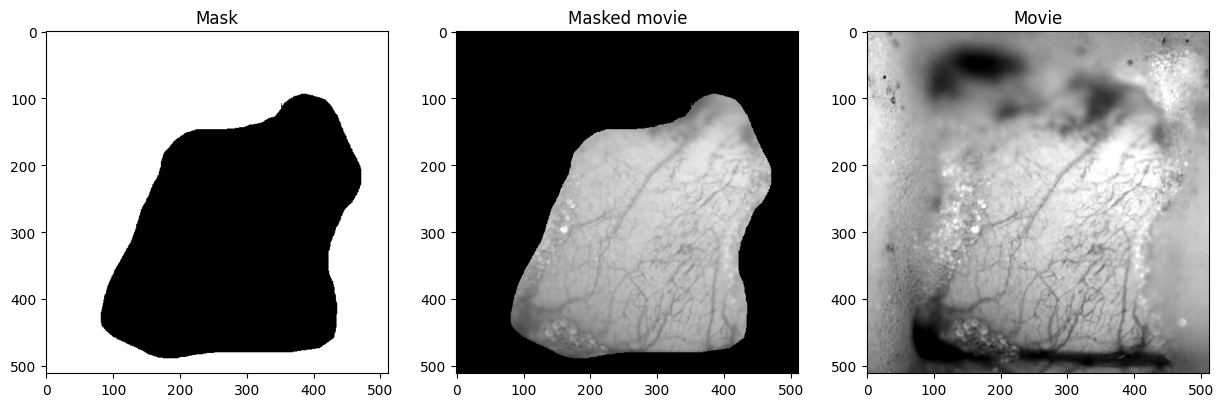

In [4]:

# --- Load movie and mask ---

# Load calcium imaging movie (3D array: time × height × width)
movie = tiff.imread(file_data)
# Remove last frame (often discarded due to artifacts or incomplete acquisition)
movie=movie[:-1,:,:]
# Load FOV mask (2D array: height × width)
mask=tiff.imread(file_mask)

# --- Prepare data for visualization ---
show1=mask # Mask image 
show2=movie.mean(axis=0) # Mean projection of the movie over time (average intensity image)

# --- Create visualization ---
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[15,5])
# --- Plot 1: Mask ---
ax1.imshow(show1,vmin=0, vmax=1,cmap='binary')
ax1.set_title(f"Mask")
# --- Plot 2: Masked movie ---
ax2.imshow(show1*show2,cmap='gray')
ax2.set_title("Masked movie")
# --- Plot 3: Mean movie ---
vmin = np.percentile(show2, 1)
vmax = np.percentile(show2, 99)
ax3.imshow(show2,vmin=vmin, vmax=vmax, cmap='gray') #vmin and vmax here determines the brightness of the picture
ax3.set_title("Movie")

Text(0.5, 1.0, 'Movie')

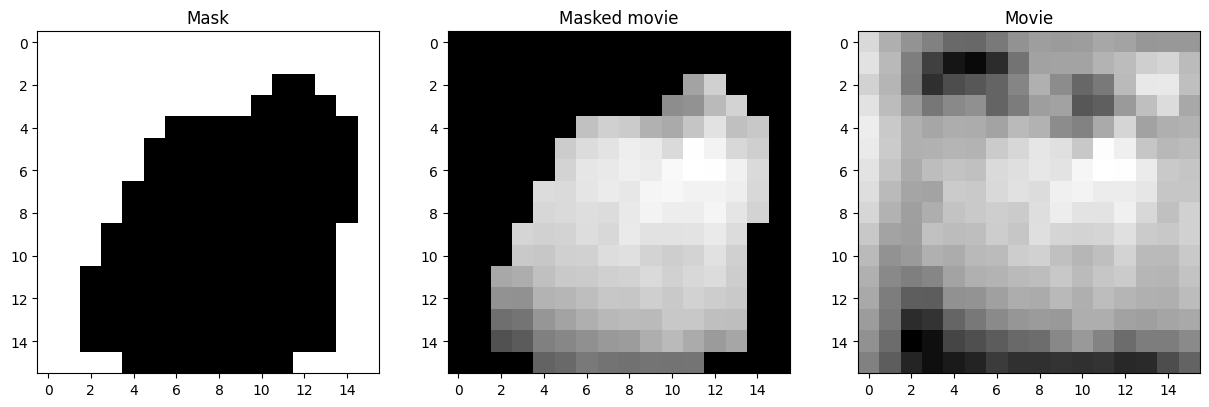

In [5]:
### Split the field of view into square ROIs using spatial downsampling.
### The scaling_factor determines the size of each ROI.
###
### For example, if the field of view is 512×512 pixels and scaling_factor = 32:
### - each ROI corresponds to a 32×32 pixel region from the original image
### - the intensity of each ROI is the average of those 32×32 pixels
### - the resulting image is reduced to 16×16 pixels → 256 ROIs in total
###
### After downsampling:
### - each pixel in the reduced movie represents one ROI (coarse-grained region)
### - analysis is performed pixel-wise on these averaged regions

scaling_factor=32 # factor by which spatial resolution is reduced

# --- Prepare container for resized movie ---
# New dimensions: (time, reduced_height, reduced_width)
dim=(movie.shape[0], int(movie.shape[2]/scaling_factor), int(movie.shape[1]/scaling_factor))
redmov=np.empty(dim)
# New 2D size for resizing each frame (width, height)
dim=(int(movie.shape[2]/scaling_factor), int(movie.shape[1]/scaling_factor))
# --- Resize each frame of the movie ---
for frame, image in enumerate(movie):
    redmov[frame] = cv.resize(image, dim, interpolation = cv.INTER_AREA)
# Convert to 16-bit integer format
redmov= redmov.astype(uint16) 
# --- Resize mask to match reduced movie resolution ---
mask=cv.resize(mask, dim, interpolation = cv.INTER_AREA)
# Convert mask to binary (ensure values are 0 or 1)
mask[mask>0]=1

# --- Prepare data for visualization ---
show1=mask # resized mask
show2=redmov.mean(axis=0) # mean projection of reduced movie

# --- Plot results (same QC visualization as before) ---
fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=[15,5])
# --- Plot 1: Mask ---
ax1.imshow(show1,vmin=0, vmax=1,cmap='binary')
ax1.set_title(f"Mask")
# --- Plot 2: Masked movie ---
ax2.imshow(show1*show2,cmap='gray')
ax2.set_title("Masked movie")
# --- Plot 3: Mean movie ---
ax3.imshow(show2,cmap='gray')
ax3.set_title("Movie")

In [6]:
# --- Parameters for preprocessing and peak detection ---
per=80                  # percentile threshold to estimate baseline (used for peak detection)
strict=3                # number of standard deviations above baseline to define a peak
order=5                 # order of Butterworth bandpass filter
dF_thresh=0.01          # minimum ΔF/F amplitude required to keep a detected peak
high_pass_thresh=0.15   #lower cutoff frequency for bandpass filter (Hz)
low_pass_thresh=3       # upper cutoff frequency for bandpass filter (Hz)

# --- Initialize Traces object ---
# Create Traces object from:
# - redmov: downsampled movie (time × height × width)
# - mask: binary FOV mask
# - t: frame rate parameter (here 100 ms -> 10 Hz equivalent)

data=Traces(redmov, mask, t=100)

# Extract raw traces (before filtering)
# Each trace corresponds to one ROI = one pixel of the downsampled movie 
raw_traces=data.traces.copy()


# --- Bandpass filtering of traces ---
# Apply Butterworth bandpass filter to each ROI trace
# Normalizes each trace after filtering
data.BPfilter(order, [high_pass_thresh,low_pass_thresh])


# --- Peak detection ---
# Detect calcium activity peaks for each ROI
# Uses:
# - percentile-based baseline estimation
# - threshold = baseline + strict × SD
# - peak filtering based on minimum amplitude (dF_thresh)
data.get_peaks_maxsegments(per,strict,dF_thresh)

# --- Identify active ROIs ---
# Find ROIs that contain at least one detected peak

data.find_active_roi()

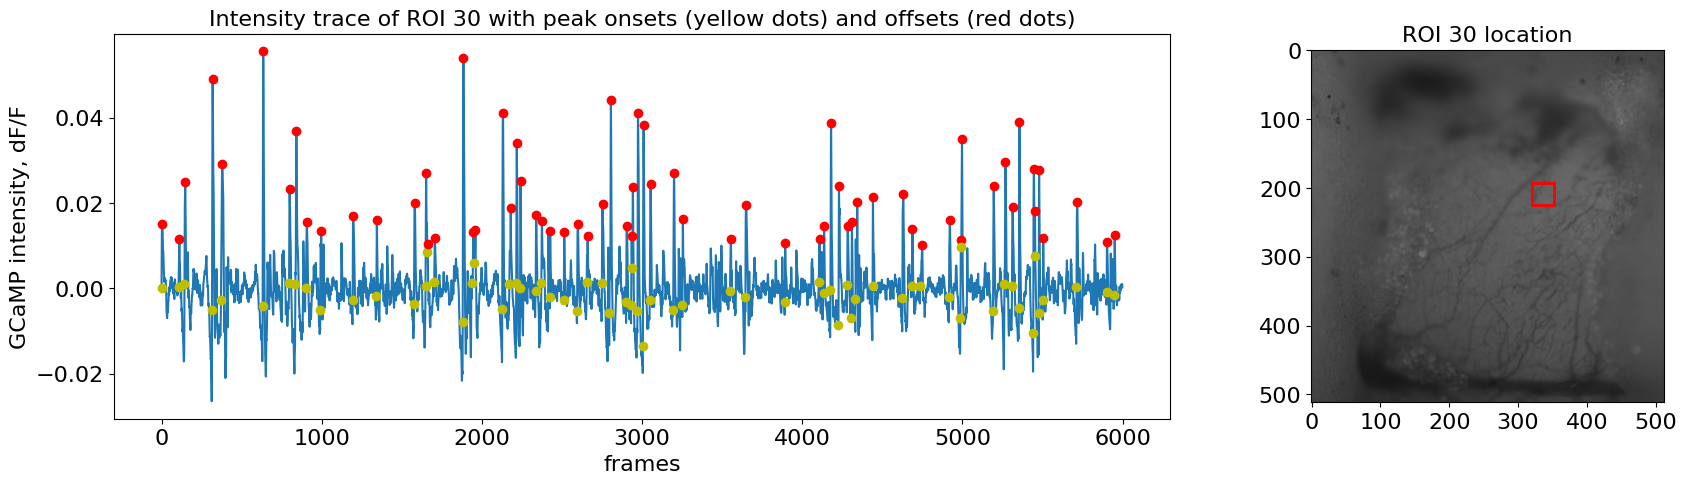

In [7]:
# --- Parameters controlling visualization and saving ---
random_flag=False # if True -> randomly select an ROI instead of fixed one
roi=30 # index of ROI to visualize (used if random_flag = False)
save_trace=True # if True -> save the trace plot as a figure file
# Mean image of original movie (used as background for ROI location)
show=movie.mean(axis=0)

# --- Optionally select a random ROI ---
if random_flag:
    roi=random.randint(0,data.nroi-1)  # Pick a random ROI index within available ROIs

# --- Convert ROI index to spatial coordinates ---
x=data.roi[roi]%redmov.shape[2]
y=data.roi[roi]//redmov.shape[1]

# --- Create figure: trace + spatial location ---
fig, (ax1,ax2)= plt.subplots(1,2,figsize=[20,5],gridspec_kw={'width_ratios': [3, 1]})
# --- Plot trace for selected ROI ---
ax1.plot(data.traces[roi,:])
# --- Mark detected peaks on the trace ---
for peak in data.peaks[roi]:
    ax1.plot(peak[0],data.traces[roi][peak[0]],'oy') # peak[0] = start (onset) → yellow marker
    ax1.plot(peak[1],data.traces[roi][peak[1]],'or') # peak[1] = maximum → red marker

# --- Formatting trace plot ---
ax1.set_title(f"Intensity trace of ROI {roi} with peak onsets (yellow dots) and offsets (red dots)", fontsize=16)
ax1.set_xlabel("frames", fontsize=16)
ax1.set_ylabel("GCaMP intensity, dF/F", fontsize=16)
for label in (ax1.get_xticklabels() + ax1.get_yticklabels()): label.set_fontsize(16)


# --- Plot spatial location of ROI ---
# Show mean image as background
ax2.imshow(show,cmap="gray", vmin=10, vmax=10000)

# --- Overlay ROI location ---
if show.shape==mask.shape:    
    # CASE 1: No resizing → mask and image same resolution
    # Mark exact pixel location
    ax2.plot(x,y,'or')
else:    
    # CASE 2: Downsampled data → ROI represents a block of original pixels
    # Draw rectangle corresponding to the original spatial region
    rect = patches.Rectangle((x*scaling_factor, y*scaling_factor), scaling_factor, scaling_factor, linewidth=2, edgecolor='r', facecolor='none')
    ax2.add_patch(rect)

# --- Formatting spatial plot --    
ax2.set_title(f"ROI {roi} location", fontsize=16) 
for label in (ax2.get_xticklabels() + ax2.get_yticklabels()): label.set_fontsize(16)

# --- Save figure if requested ---    
if save_trace:
    savefig(name_trace)


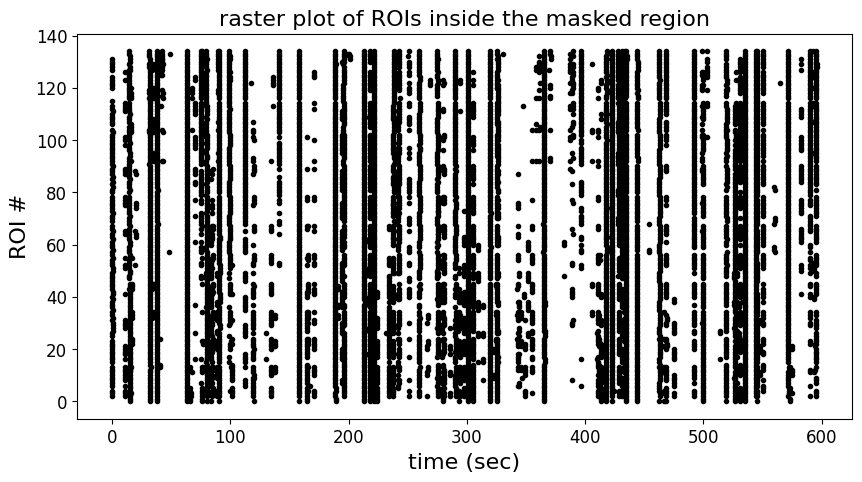

In [8]:
# --- Generate raster plot of detected peaks ---
# Create a raster representation of activity:
# - rows = time (frames)
# - columns = ROIs
# - value = 1 where a peak occurs, 0 otherwise
# Also generates a visualization (dot plot) of peak timings across ROIs

data.find_raster()
# Save the raster plot figure to file
savefig(name_raster)


In [9]:
# --- Define spatial calibration and ROI area ---
# Field of view: 512 x 512 pixels
# Spatial resolution: 6.55 µm per pixel (micrometers per pixel)
# Downsampling uses scaling_factor = 32:
#   -> each ROI corresponds to a 32 x 32 pixel region of the original image
#   -> resulting grid: 16 x 16 = 256 ROIs

# Spatial resolution (µm per pixel)
resolution = 6.55

# --- Compute area of a single ROI ---
# Convert ROI size from pixels -> micrometers:
# (scaling_factor x resolution) gives length of one ROI side in µm
# Squaring gives area in µm²
roi_area = (scaling_factor * resolution) ** 2

# Convert µm² -> mm² (1 mm² = 1,000,000 µm²)
roi_area = roi_area / 1_000_000


# --- Output area information ---
# Area of one ROI (square region)
print('ROI area', roi_area, 'mm2')

# Total covered area (all ROIs inside mask)
# data.nroi = number of ROI pixels inside mask
print('mask area', roi_area * data.nroi, 'mm2')

ROI area 0.04393216 mm2
mask area 5.9308416 mm2


total number of events 483


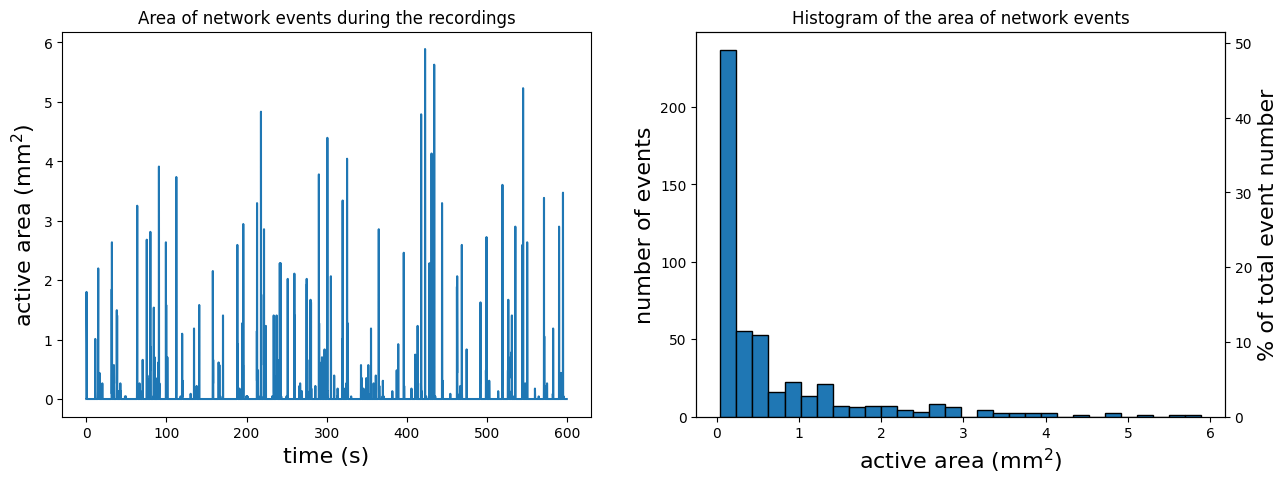

In [10]:
# --- Compute population (network) activity in spatial units ---
# data.raster -> binary matrix (time × ROIs), 1 = active (peak), 0 = inactive
# Sum across ROIs -> number of active ROIs at each time point
# Multiply by roi_area -> convert from "number of ROIs" to physical area (mm²)

synch=data.raster.sum(axis=1)*roi_area
# Create figure with two subplots: time series + histogram
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[15,5])
# Create secondary y-axis for percentage histogram
ax3 = ax2.twinx()

# Plot active area over time:
# x-axis: time (converted from frames to seconds using frame_rate)
# y-axis: total active area (mm^2)
ax1.plot(np.array(range(len(synch)))*data.frame_rate/1000,synch)
# Label axes and title
ax1.set_xlabel("time (s)", fontsize=16)
ax1.set_ylabel("active area (mm$^2$)", fontsize=16)
ax1.set_title("Area of network events during the recordings")

# Remove time points with no activity (keep only frames with ≥1 active ROI)
synch=synch[synch!=0]
# Save active area values (event sizes) to file
np.savetxt(name_netevents,synch)
# Print total number of events (non-zero frames)
print('total number of events', len(synch))

# Compute histogram of event sizes (active area)
counts, bins=np.histogram(synch, bins=30)
# Plot histogram: absolute counts (number of events in each bin)
ax2.hist(bins[:-1], bins, weights=counts)
# Label axes and title
ax2.set_xlabel("active area (mm$^2$)", fontsize=16)
ax2.set_ylabel("number of events", fontsize=16)
ax2.set_title("Histogram of the area of network events")

# Plot histogram again on secondary axis: percentage of total events
# (normalized version of the same histogram)
ax3.hist(bins[:-1], bins, weights=100*counts/len(synch),color=None, edgecolor='k')
# Label secondary y-axis
ax3.set_ylabel("% of total event number", fontsize=16)

# Save the combined figure (time series + histogram)
savefig(name_netevents_plot)


In [11]:

# --- Compute total recording time in seconds ---
# data.nframes is the number of frames
# data.frame_rate is the time per frame (ms)
# -> convert to total duration in seconds
time=data.nframes*data.frame_rate/1000

# --- Classify events based on active area ---
loc=synch[synch<=0.5]               # Local events: small spatial extent (≤ 0.5 mm²)
med=synch[(synch>0.5)&(synch<=2)]   # Medium events: intermediate size (0.5 < area ≤ 2 mm²)
glb=synch[synch>2]                  # Global events: large network activity (> 2 mm²

# --- Create DataFrame to summarize event statistics ---
events=pd.DataFrame()
# number of events in each category divided by total recording time
events['frequency (Hz)']=[len(loc)/time, len(med)/time, len(glb)/time]
# Median area (mm²) for each event category
events['median area (mm2)']=[median(loc),median(med),median(glb)]
# --- Label rows for clarity ---
events.index=['local (area<0.5 mm2)','medium (0.5<area<2 mm2)','global (area>2 mm2)']
# --- Save results to Excel file ---
events.to_excel(name_events)
events

,frequency (Hz),median area (mm2)
local (area<0.5 mm2),0.523421,0.131796
medium (0.5<area<2 mm2),0.205034,0.922575
global (area>2 mm2),0.076679,2.833624


In [12]:
# --- Compute activity frequency per ROI ---

# Calculate fraction of frames in which each ROI is active
# Returned values: events per frame
activefr=data.find_active_frames() #in events/frame

# --- Save activity frequency to file (converted to Hz) ---
file = open(name_actfr, "w")
for element in activefr:
    file.write(str(element/data.frame_rate*1000) + "\n") #in events/s (Hz)
file. close()


# --- Compute inter-event intervals ---

# Extract list of time intervals between consecutive peaks
# (only for active ROIs, already converted to seconds inside the method)
interval=data.export_intdata()

# --- Save inter-event intervals to file---
file = open(name_int, "w")
for element in interval:
    file.write(str(element) + "\n")
file. close()
